In [1]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
from lab_utils_uni import plt_house_x, plt_contour_wgrad, plt_divergence, plt_gradients

In [2]:
# Load our data set
x_train = np.array([1.0, 2.0])   #features
y_train = np.array([300.0, 500.0])   #target value

In [6]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost = 0

    for i in range(m):
        f_wb = w*x[i]+b
        cost += (f_wb - y[i])**2
    total_cost = 1/(2*m) *cost

    return total_cost

In [3]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w*x[i]+b
        dj_dw_i = (f_wb - y[i])* x[i]
        dj_db_i = f_wb - y[i]
        dj_dw += dj_dw_i
        dj_db += dj_db_i
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    return dj_dw, dj_db

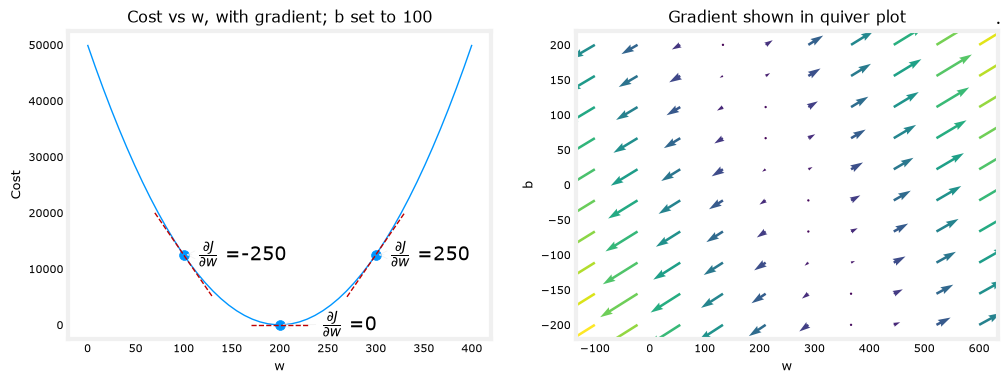

In [7]:
plt_gradients(x_train, y_train, compute_cost, compute_gradient)
plt.show()

In [8]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    """
    Performs gradient descent to fit w,b. Updates w,b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
    x (ndarray (m,))  : Data, m examples 
    y (ndarray (m,))  : target values
    w_in,b_in (scalar): initial values of model parameters  
    alpha (float):     Learning rate
    num_iters (int):   number of iterations to run gradient descent
    cost_function:     function to call to produce cost
    gradient_function: function to call to produce gradient
    
    Returns:
    w (scalar): Updated value of parameter after running gradient descent
    b (scalar): Updated value of parameter after running gradient descent
    J_history (List): History of cost values
    p_history (list): History of parameters [w,b] 
    """
    j_history = []
    p_history = []
    w = w_in
    b = b_in

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w, b)

        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        if i < 100000:
            j_history.append(cost_function(x, y, w, b))
            p_history.append([w, b])

        if i % math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                f"w: {w: 0.3e}, b:{b: 0.5e}")

    return w, b, j_history, p_history